# WiDS Datathon 2026 — Week 1: EDA & Baseline
**Wildfire Survival Analysis: Predicting Evacuation Zone Threats**

## Objectives
1. Reproducible setup & schema validation
2. Data audit (missing values, dtypes, ranges)
3. LLM-readable EDA (text + numeric summaries, not just plots)
4. Survival-aware feature analysis (censoring patterns, Kaplan-Meier)
5. Leakage hunt
6. Local metric implementation (C-index + IPCW Brier + Hybrid)
7. Baseline model ladder → first valid submission

### Key dataset facts
- Train: 221 rows | 69 events (hits) | 152 censored
- Test: 95 rows (no targets)
- Target: `time_to_hit_hours` (survival time) + `event` (1=hit, 0=censored)
- Predict: `prob_12h`, `prob_24h`, `prob_48h`, `prob_72h`
- Metric: `0.3 × C-index + 0.7 × (1 − Weighted Brier Score)`
- WBS weights: `0.3×@24h + 0.4×@48h + 0.3×@72h`

---
## 0. Setup & Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullAFTFitter
from lifelines.statistics import multivariate_logrank_test
from lifelines.utils import concordance_index
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, brier_score, integrated_brier_score
from sksurv.linear_model import CoxPHSurvivalAnalysis

# ML
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 120)
np.set_printoptions(precision=4, suppress=True)

SEED = 42
np.random.seed(SEED)


# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = "../data"
OUTPUT_DIR = "../outputs"
SUBMISSION_DIR = "../submissions"

DATA_DIR = Path(DATA_DIR)
OUTPUT_DIR = Path(OUTPUT_DIR)
SUBMISSION_DIR = Path(SUBMISSION_DIR)

HORIZONS = [12, 24, 48, 72]     # prediction horizons in hours
HORIZON_COLS = ['prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']

print('Setup complete.')
print(f'Data dir : {DATA_DIR.resolve()}')
print(f'Output dir: {OUTPUT_DIR.resolve()}')
print(f'Submission dir: {SUBMISSION_DIR.resolve()}')

Setup complete.
Data dir : /Users/mellissahafis/Documents/WiDS_Global_Datathon_2026/data
Output dir: /Users/mellissahafis/Documents/WiDS_Global_Datathon_2026/outputs
Submission dir: /Users/mellissahafis/Documents/WiDS_Global_Datathon_2026/submissions


---
## 1. Load Data & Schema Validation

In [3]:
# ── Load ──────────────────────────────────────────────────────────────────────
train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')
sample_sub = pd.read_csv(DATA_DIR / 'sample_submission.csv')
meta  = pd.read_csv(DATA_DIR / 'metaData.csv')

print('=' * 60)
print('SCHEMA VALIDATION')
print('=' * 60)

# Expected columns
TARGET_COLS  = ['time_to_hit_hours', 'event']
ID_COL       = 'event_id'

FEATURE_COLS = [
    # Temporal coverage
    'num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h',
    # Growth
    'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h',
    'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth',
    'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m',
    'radial_growth_rate_m_per_h',
    # Centroid kinematics
    'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg',
    'spread_bearing_sin', 'spread_bearing_cos',
    # Distance to evac zones
    'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h',
    'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h',
    'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h',
    # Directionality
    'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed',
    # Temporal metadata
    'event_start_hour', 'event_start_dayofweek', 'event_start_month'
]

checks = {
    'train rows'        : len(train),
    'test rows'         : len(test),
    'train features'    : len([c for c in FEATURE_COLS if c in train.columns]),
    'expected features' : len(FEATURE_COLS),
    'targets present'   : all(c in train.columns for c in TARGET_COLS),
    'id unique train'   : train[ID_COL].nunique() == len(train),
    'id unique test'    : test[ID_COL].nunique() == len(test),
    'train/test id overlap': len(set(train[ID_COL]) & set(test[ID_COL])),
    'sample_sub ids match test': set(sample_sub[ID_COL]) == set(test[ID_COL]),
}

for k, v in checks.items():
    status = '✓' if v not in [False, 0] else '✗'
    print(f'  {status}  {k:35s} : {v}')

missing_features = [c for c in FEATURE_COLS if c not in train.columns]
if missing_features:
    print(f'\n  ⚠ Missing feature columns: {missing_features}')
else:
    print('\n  ✓ All 34 expected feature columns present in train')

SCHEMA VALIDATION
  ✓  train rows                          : 221
  ✓  test rows                           : 95
  ✓  train features                      : 34
  ✓  expected features                   : 34
  ✓  targets present                     : True
  ✓  id unique train                     : True
  ✓  id unique test                      : True
  ✗  train/test id overlap               : 0
  ✓  sample_sub ids match test           : True

  ✓ All 34 expected feature columns present in train


---
## 2. Data Audit — LLM-Readable Summary

In [4]:
print('=' * 60)
print('DATA AUDIT — MISSING VALUES')
print('=' * 60)

def audit_missing(df, name):
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    result = pd.DataFrame({'missing_count': miss, 'missing_pct': miss_pct})
    result = result[result.missing_count > 0].sort_values('missing_count', ascending=False)
    if len(result) == 0:
        print(f'  {name}: NO missing values  ✓')
    else:
        print(f'  {name}: {len(result)} columns with missing values')
        print(result.to_string())
    return result

_ = audit_missing(train, 'train')
print()
_ = audit_missing(test, 'test')

DATA AUDIT — MISSING VALUES
  train: NO missing values  ✓

  test: NO missing values  ✓


In [5]:
print('=' * 60)
print('DATA AUDIT — DTYPES & CONSTANT COLUMNS')
print('=' * 60)

# Dtypes
dtype_summary = train[FEATURE_COLS].dtypes.value_counts()
print('\nFeature dtype counts:')
print(dtype_summary.to_string())

# Constant columns (zero variance)
constant_cols = [c for c in FEATURE_COLS if train[c].nunique() <= 1]
print(f'\nConstant columns (nunique <= 1): {constant_cols if constant_cols else "None"}')

# Near-constant (< 5 unique values)
low_var_cols = [(c, train[c].nunique()) for c in FEATURE_COLS if train[c].nunique() < 5]
print('\nLow-cardinality columns (< 5 unique values):')
for col, n in low_var_cols:
    vc = train[col].value_counts().to_dict()
    print(f'  {col}: {n} unique — {vc}')

DATA AUDIT — DTYPES & CONSTANT COLUMNS

Feature dtype counts:
float64    29
int64       5

Constant columns (nunique <= 1): None

Low-cardinality columns (< 5 unique values):
  low_temporal_resolution_0_5h: 2 unique — {1: 161, 0: 60}


In [6]:
print('=' * 60)
print('DATA AUDIT — FEATURE STATISTICS (LLM-READABLE)')
print('=' * 60)

stats = train[FEATURE_COLS].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
stats['skewness'] = train[FEATURE_COLS].skew().round(3)
stats['kurtosis'] = train[FEATURE_COLS].kurt().round(3)
stats['neg_count'] = (train[FEATURE_COLS] < 0).sum()
stats['zero_count'] = (train[FEATURE_COLS] == 0).sum()

print(stats[['mean', 'std', 'min', '5%', '50%', '95%', 'max',
             'skewness', 'neg_count', 'zero_count']].to_string())

# Flag highly skewed features
print('\nHighly skewed features (|skewness| > 3):')
skewed = stats[stats['skewness'].abs() > 3]['skewness'].sort_values(key=abs, ascending=False)
print(skewed.to_string() if len(skewed) > 0 else '  None')

DATA AUDIT — FEATURE STATISTICS (LLM-READABLE)
                                    mean         std        min        5%        50%         95%         max  skewness  neg_count  zero_count
num_perimeters_0_5h               2.0633      2.5789     1.0000    1.0000     1.0000      7.0000     17.0000    3.1740          0           0
dt_first_last_0_5h                0.9799      1.7381     0.0000    0.0000     0.0000      4.7976      4.9945    1.4090          0         160
low_temporal_resolution_0_5h      0.7285      0.4457     0.0000    0.0000     1.0000      1.0000      1.0000   -1.0350          0          60
area_first_ha                   619.1316   1447.7237     0.0375    2.0115   110.1493   2300.0090  11942.3921    4.7210          0           0
area_growth_abs_0_5h             26.3324    187.4370    -0.0000    0.0000     0.0000     35.3213   2508.0414   11.2310          1         196
area_growth_rel_0_5h              0.1789      1.3020    -0.0000    0.0000     0.0000      0.4834     

In [7]:
print('=' * 60)
print('DATA AUDIT — TRAIN vs TEST DISTRIBUTION SHIFT')
print('=' * 60)

shift_report = []
for col in FEATURE_COLS:
    tr_mean = train[col].mean()
    te_mean = test[col].mean()
    tr_std  = train[col].std() + 1e-9
    delta_z = abs(tr_mean - te_mean) / tr_std   # standardised mean difference
    shift_report.append({'feature': col, 'train_mean': tr_mean, 'test_mean': te_mean,
                         'std_mean_diff': round(delta_z, 3)})

shift_df = pd.DataFrame(shift_report).sort_values('std_mean_diff', ascending=False)
print('\nTop 10 features by standardized mean difference (train vs test):')
print(shift_df.head(10).to_string(index=False))
print('\nFeatures with std_mean_diff > 0.5 (potential distribution shift):')
shifted = shift_df[shift_df.std_mean_diff > 0.5]
print(shifted.to_string(index=False) if len(shifted) > 0 else '  None')

DATA AUDIT — TRAIN vs TEST DISTRIBUTION SHIFT

Top 10 features by standardized mean difference (train vs test):
                   feature  train_mean  test_mean  std_mean_diff
             area_first_ha    619.1316   891.2998         0.1880
     event_start_dayofweek      2.8416     2.5474         0.1490
radial_growth_rate_m_per_h      7.7703     2.3343         0.1440
             alignment_abs      0.1727     0.1280         0.1360
 area_growth_rate_ha_per_h      6.1671     0.7261         0.1340
           radial_growth_m     29.4296     9.9763         0.1340
    centroid_speed_m_per_h     11.9535     4.4361         0.1280
      area_growth_abs_0_5h     26.3324     3.1279         0.1240
              log1p_growth      0.3893     0.2347         0.1150
   centroid_displacement_m     44.2779    19.1141         0.1150

Features with std_mean_diff > 0.5 (potential distribution shift):
  None


---
## 3. Target Analysis

In [8]:
print('=' * 60)
print('TARGET ANALYSIS')
print('=' * 60)

n_total   = len(train)
n_events  = train['event'].sum()
n_censored = n_total - n_events

print(f'\nTotal fires     : {n_total}')
print(f'Events (hit=1)  : {n_events}  ({n_events/n_total*100:.1f}%)')
print(f'Censored (hit=0): {n_censored}  ({n_censored/n_total*100:.1f}%)')

# time_to_hit_hours by event status
print('\ntime_to_hit_hours stats by event status:')
ttl_stats = train.groupby('event')['time_to_hit_hours'].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
print(ttl_stats.to_string())

# Horizon feasibility: how many hits occur before each horizon?
print('\nCumulative hits by horizon (among event=1 fires):')
hits = train[train['event'] == 1]['time_to_hit_hours']
for h in HORIZONS:
    n = (hits <= h).sum()
    print(f'  By {h:2d}h: {n:2d} / {n_events} fires hit ({n/n_events*100:.1f}%)')

# Censored: distribution of last-observed times
censored = train[train['event'] == 0]['time_to_hit_hours']
print(f'\nCensored fires — last observed time distribution:')
print(censored.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(2).to_string())
print(f'  Fires censored exactly at 72h: {(censored == 72).sum()}')
print(f'  Fires censored before 72h    : {(censored < 72).sum()}')

TARGET ANALYSIS

Total fires     : 221
Events (hit=1)  : 69  (31.2%)
Censored (hit=0): 152  (68.8%)

time_to_hit_hours stats by event status:
         count    mean     std    min     10%     25%     50%     75%     90%     max
event                                                                                
0     152.0000 50.0956 19.4021 0.3745 18.7167 38.1752 61.1689 65.1137 66.4257 66.9945
1      69.0000  9.9699 14.5285 0.0012  0.4033  0.8889  3.5348 14.3234 23.1494 66.9205

Cumulative hits by horizon (among event=1 fires):
  By 12h: 49 / 69 fires hit (71.0%)
  By 24h: 63 / 69 fires hit (91.3%)
  By 48h: 66 / 69 fires hit (95.7%)
  By 72h: 69 / 69 fires hit (100.0%)

Censored fires — last observed time distribution:
count   152.0000
mean     50.1000
std      19.4000
min       0.3700
10%      18.7200
25%      38.1800
50%      61.1700
75%      65.1100
90%      66.4300
max      66.9900
  Fires censored exactly at 72h: 0
  Fires censored before 72h    : 152


In [ ]:
# ── Visual: survival time distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# KM curve
kmf = KaplanMeierFitter()
kmf.fit(train['time_to_hit_hours'], event_observed=train['event'])
kmf.plot_survival_function(ax=axes[0], ci_show=True)
axes[0].set_title('Overall Kaplan-Meier Curve')
axes[0].set_xlabel('Time (hours)')
axes[0].set_ylabel('Survival Probability')
for h in HORIZONS:
    axes[0].axvline(h, ls='--', color='gray', alpha=0.5, lw=0.8)
    axes[0].text(h+0.5, 0.02, f'{h}h', fontsize=7, color='gray')

# Hit time distribution (events only)
axes[1].hist(train[train['event']==1]['time_to_hit_hours'], bins=20,
             color='salmon', edgecolor='white')
axes[1].set_title('Time-to-Hit Distribution (Events Only)')
axes[1].set_xlabel('Hours to reach evac zone')
for h in HORIZONS:
    axes[1].axvline(h, ls='--', color='steelblue', alpha=0.7, lw=1)

# Censored time distribution
axes[2].hist(train[train['event']==0]['time_to_hit_hours'], bins=20,
             color='steelblue', edgecolor='white')
axes[2].set_title('Last-Observed Time (Censored Fires)')
axes[2].set_xlabel('Last observed time (hours)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# KM survival probability at each horizon (text output)
print('\nKaplan-Meier: Estimated survival probability at each horizon')
print('(P(fire does NOT hit evac zone by horizon H))')
for h in HORIZONS:
    sf = kmf.survival_function_at_times([h]).values[0]
    hit_prob = 1 - sf
    print(f'  P(hit by {h:2d}h) ≈ {hit_prob:.4f}  |  P(survive past {h:2d}h) ≈ {sf:.4f}')

---
## 4. Feature Analysis — LLM-Readable

In [9]:
print('=' * 60)
print('FEATURE ANALYSIS — UNIVARIATE SURVIVAL ASSOCIATION')
print('=' * 60)
print('For each feature: C-index vs survival time (higher = better predictor)')
print('  C-index > 0.6 → meaningful signal')
print('  C-index < 0.5 → inverse predictor (or noise)')
print()

results = []
for col in FEATURE_COLS:
    vals = train[col].fillna(train[col].median())

    # Skip constant features — concordance_index raises ZeroDivisionError
    if vals.nunique() <= 1:
        results.append({'feature': col, 'c_index': np.nan, 'direction': 'constant — skipped'})
        continue

    try:
        ci     = concordance_index(train['time_to_hit_hours'], -vals, train['event'])
        ci_inv = concordance_index(train['time_to_hit_hours'],  vals, train['event'])
        best_ci   = max(ci, ci_inv)
        direction = 'higher→sooner' if ci > ci_inv else 'lower→sooner'
        results.append({'feature': col, 'c_index': round(best_ci, 4), 'direction': direction})
    except Exception as e:
        results.append({'feature': col, 'c_index': np.nan, 'direction': f'error: {e}'})

feat_ci = pd.DataFrame(results).sort_values('c_index', ascending=False, na_position='last')
print(feat_ci.to_string(index=False))

FEATURE ANALYSIS — UNIVARIATE SURVIVAL ASSOCIATION
For each feature: C-index vs survival time (higher = better predictor)
  C-index > 0.6 → meaningful signal
  C-index < 0.5 → inverse predictor (or noise)

                     feature  c_index     direction
            dist_min_ci_0_5h   0.9095  lower→sooner
         num_perimeters_0_5h   0.7177 higher→sooner
          dt_first_last_0_5h   0.7035 higher→sooner
               alignment_abs   0.6992 higher→sooner
low_temporal_resolution_0_5h   0.6947  lower→sooner
     centroid_displacement_m   0.6192 higher→sooner
      centroid_speed_m_per_h   0.6191 higher→sooner
          spread_bearing_cos   0.6186  lower→sooner
          spread_bearing_deg   0.6173 higher→sooner
                log1p_growth   0.6130 higher→sooner
   area_growth_rate_ha_per_h   0.6064 higher→sooner
        area_growth_abs_0_5h   0.6062 higher→sooner
  radial_growth_rate_m_per_h   0.6059 higher→sooner
             radial_growth_m   0.6057 higher→sooner
        area_g

In [10]:
print('=' * 60)
print('FEATURE ANALYSIS — MEAN DIFFERENCES (EVENT vs CENSORED)')
print('=' * 60)

hits_df     = train[train['event'] == 1][FEATURE_COLS]
censored_df = train[train['event'] == 0][FEATURE_COLS]

diff_report = []
for col in FEATURE_COLS:
    m_hit  = hits_df[col].mean()
    m_cens = censored_df[col].mean()
    std    = train[col].std() + 1e-9
    effect = (m_hit - m_cens) / std
    diff_report.append({
        'feature': col,
        'mean_hit': round(m_hit, 4),
        'mean_censored': round(m_cens, 4),
        'cohen_d': round(effect, 3)
    })

diff_df = pd.DataFrame(diff_report).sort_values('cohen_d', key=abs, ascending=False)
print('\nTop features by |Cohen d| (event vs censored):')
print(diff_df.head(15).to_string(index=False))

print('\nFeatures with |Cohen d| > 0.4 (moderate-large effect):')
strong = diff_df[diff_df['cohen_d'].abs() > 0.4]
print(strong.to_string(index=False) if len(strong) > 0 else '  None')

FEATURE ANALYSIS — MEAN DIFFERENCES (EVENT vs CENSORED)

Top features by |Cohen d| (event vs censored):
                     feature  mean_hit  mean_censored  cohen_d
            dist_min_ci_0_5h 2285.8183    179832.3031  -1.0360
low_temporal_resolution_0_5h    0.4783         0.8421  -0.8160
         num_perimeters_0_5h    3.4783         1.4211   0.7980
          dt_first_last_0_5h    1.8883         0.5675   0.7600
               alignment_abs    0.3429         0.0954   0.7520
          spread_bearing_cos    0.7220         0.9669  -0.6960
                log1p_growth    0.9703         0.1256   0.6300
          spread_bearing_deg   33.2069         4.9494   0.6050
         log_area_ratio_0_5h    0.1674         0.0191   0.4940
  radial_growth_rate_m_per_h   19.8157         2.3024   0.4630
             radial_growth_m   74.3432         9.0412   0.4510
      centroid_speed_m_per_h   30.2176         3.6626   0.4510
     centroid_displacement_m  111.6571        13.6912   0.4480
          spre

In [11]:
print('=' * 60)
print('FEATURE ANALYSIS — CORRELATION MATRIX (TEXT)')
print('=' * 60)

corr = train[FEATURE_COLS].corr().round(3)

# Find highly correlated pairs
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        c = corr.iloc[i, j]
        if abs(c) > 0.85:
            high_corr_pairs.append({
                'feature_1': corr.columns[i],
                'feature_2': corr.columns[j],
                'correlation': c
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', key=abs, ascending=False)
print(f'\nHighly correlated pairs (|r| > 0.85): {len(high_corr_df)} found')
if len(high_corr_df) > 0:
    print(high_corr_df.to_string(index=False))

# Correlation with targets
print('\nCorrelation of features with time_to_hit_hours (all rows):')
target_corr = train[FEATURE_COLS + ['time_to_hit_hours']].corr()['time_to_hit_hours'].drop('time_to_hit_hours')
target_corr = target_corr.sort_values(key=abs, ascending=False)
print(target_corr.round(4).to_string())

FEATURE ANALYSIS — CORRELATION MATRIX (TEXT)

Highly correlated pairs (|r| > 0.85): 45 found
                   feature_1                    feature_2  correlation
        area_growth_rel_0_5h         relative_growth_0_5h       1.0000
         dist_change_ci_0_5h          projected_advance_m      -1.0000
         dist_change_ci_0_5h        closing_speed_m_per_h      -0.9980
       closing_speed_m_per_h          projected_advance_m       0.9980
            dist_std_ci_0_5h    closing_speed_abs_m_per_h       0.9970
          dist_slope_ci_0_5h          projected_advance_m      -0.9930
          dist_slope_ci_0_5h        closing_speed_m_per_h      -0.9930
         dist_change_ci_0_5h           dist_slope_ci_0_5h       0.9930
        area_growth_abs_0_5h    area_growth_rate_ha_per_h       0.9910
             radial_growth_m      centroid_displacement_m       0.9890
  radial_growth_rate_m_per_h       centroid_speed_m_per_h       0.9890
  radial_growth_rate_m_per_h      centroid_displacement

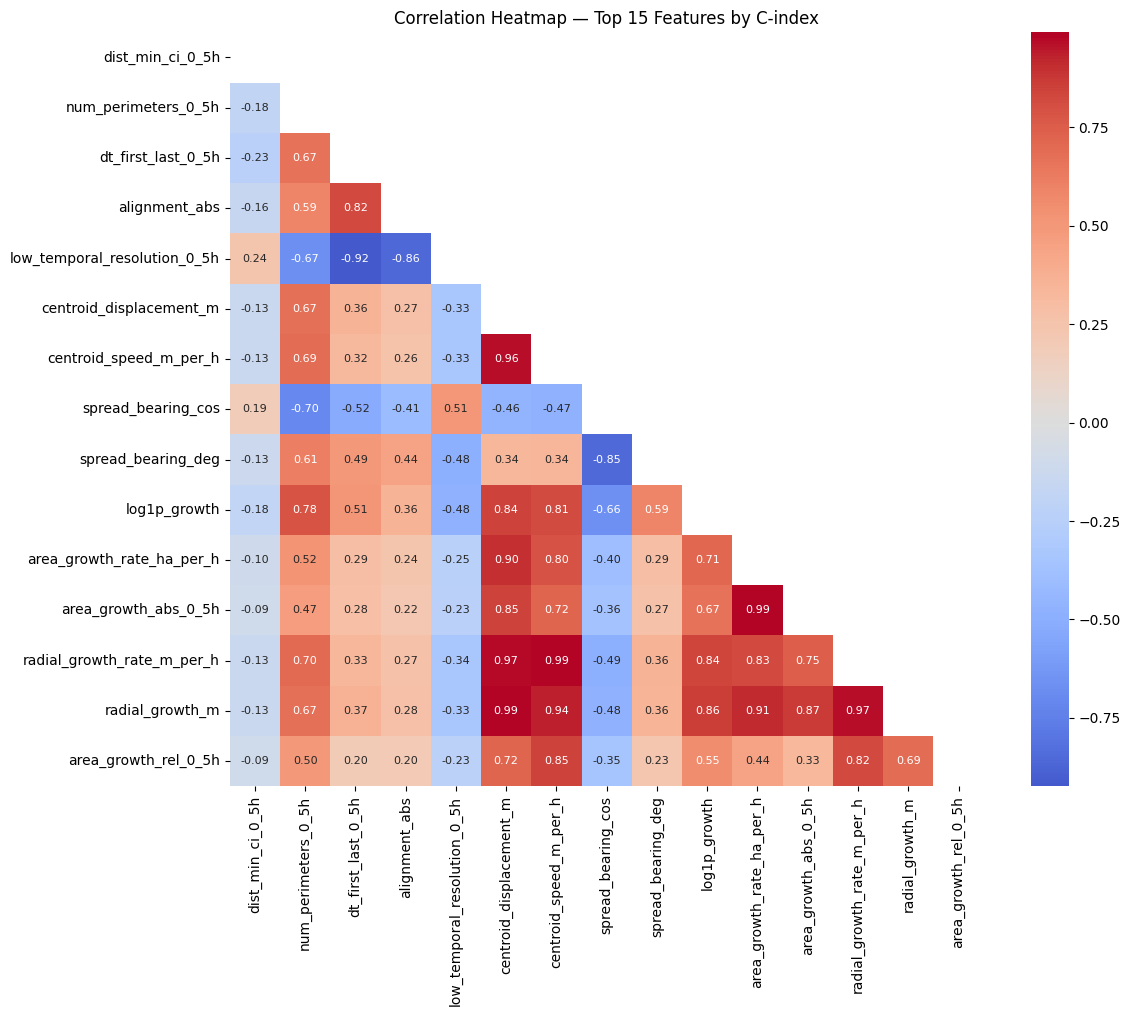

In [12]:
# ── Visual: correlation heatmap (key features only) ───────────────────────────
# Select top-15 features by c-index for readability
top_features = feat_ci.head(15)['feature'].tolist()

fig, ax = plt.subplots(figsize=(12, 10))
corr_top = train[top_features].corr()
mask = np.triu(np.ones_like(corr_top, dtype=bool))
sns.heatmap(corr_top, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Top 15 Features by C-index')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

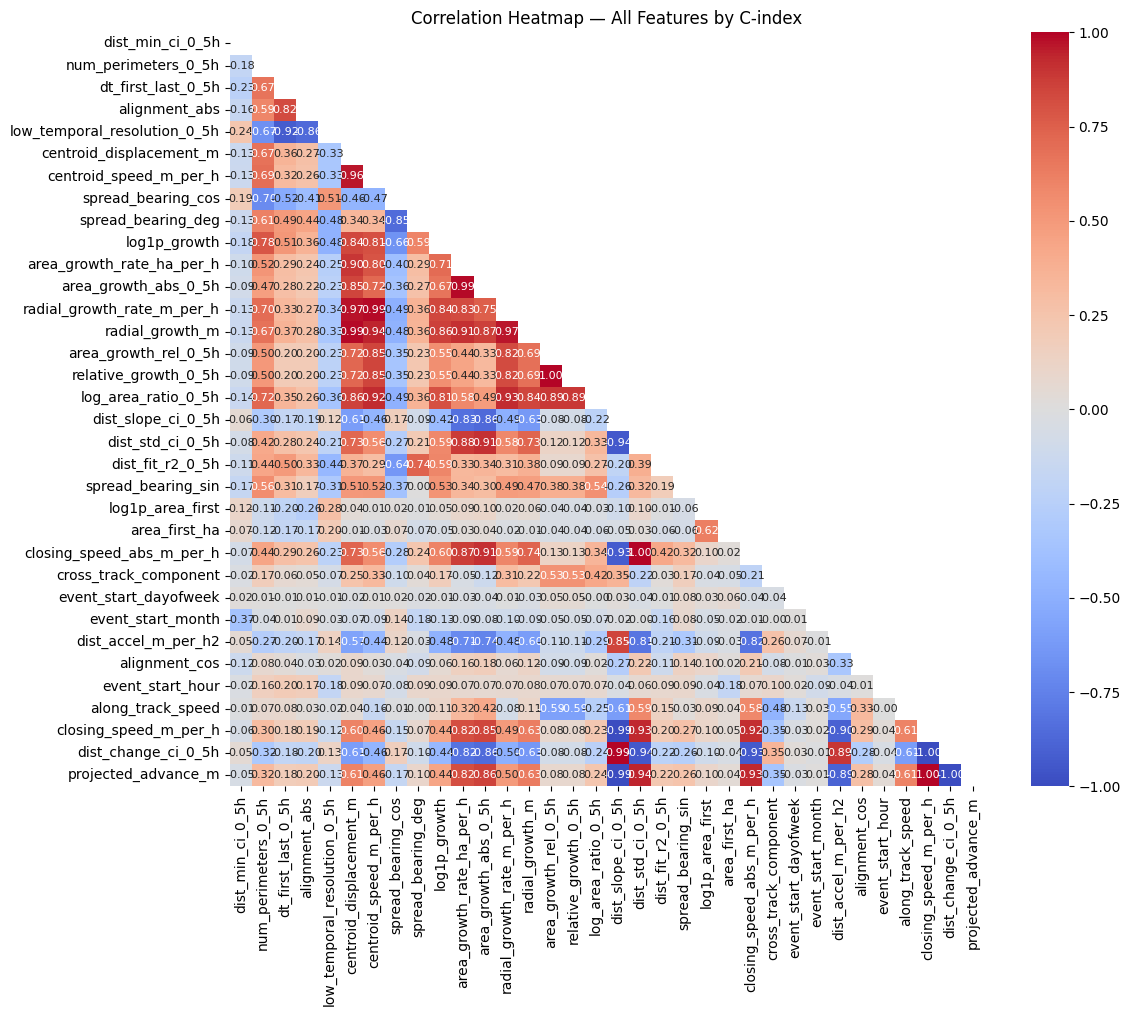

In [13]:
# ── Visual: correlation heatmap (key features only) ───────────────────────────
# Select ALL features by c-index for readability
top_features = feat_ci['feature'].tolist()

fig, ax = plt.subplots(figsize=(12, 10))
corr_top = train[top_features].corr()
mask = np.triu(np.ones_like(corr_top, dtype=bool))
sns.heatmap(corr_top, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — All Features by C-index')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Kaplan-Meier by Feature Quartiles

KAPLAN-MEIER STRATIFIED ANALYSIS (text summary)

  dist_min_ci_0_5h:
    Low : n= 73, events=69, median_survival=3.7h
    Mid : n= 75, events= 0, median_survival=inf (never hit 50%)
    High: n= 73, events= 0, median_survival=inf (never hit 50%)
    log-rank p-value: 0.0000 (significant)

  num_perimeters_0_5h:
    Low : n=160, events=32, median_survival=inf (never hit 50%)
    High: n= 61, events=37, median_survival=3.8h
    log-rank p-value: 0.0000 (significant)

  dt_first_last_0_5h:
    Low : n=160, events=32, median_survival=inf (never hit 50%)
    High: n= 61, events=37, median_survival=3.8h
    log-rank p-value: 0.0000 (significant)

  alignment_abs:
    Low : n=160, events=32, median_survival=inf (never hit 50%)
    High: n= 61, events=37, median_survival=3.8h
    log-rank p-value: 0.0000 (significant)

  low_temporal_resolution_0_5h: skipped — fewer than 2 groups with n≥5

  centroid_displacement_m:
    Low : n=196, events=51, median_survival=66.9h
    High: n= 25, events=18, 

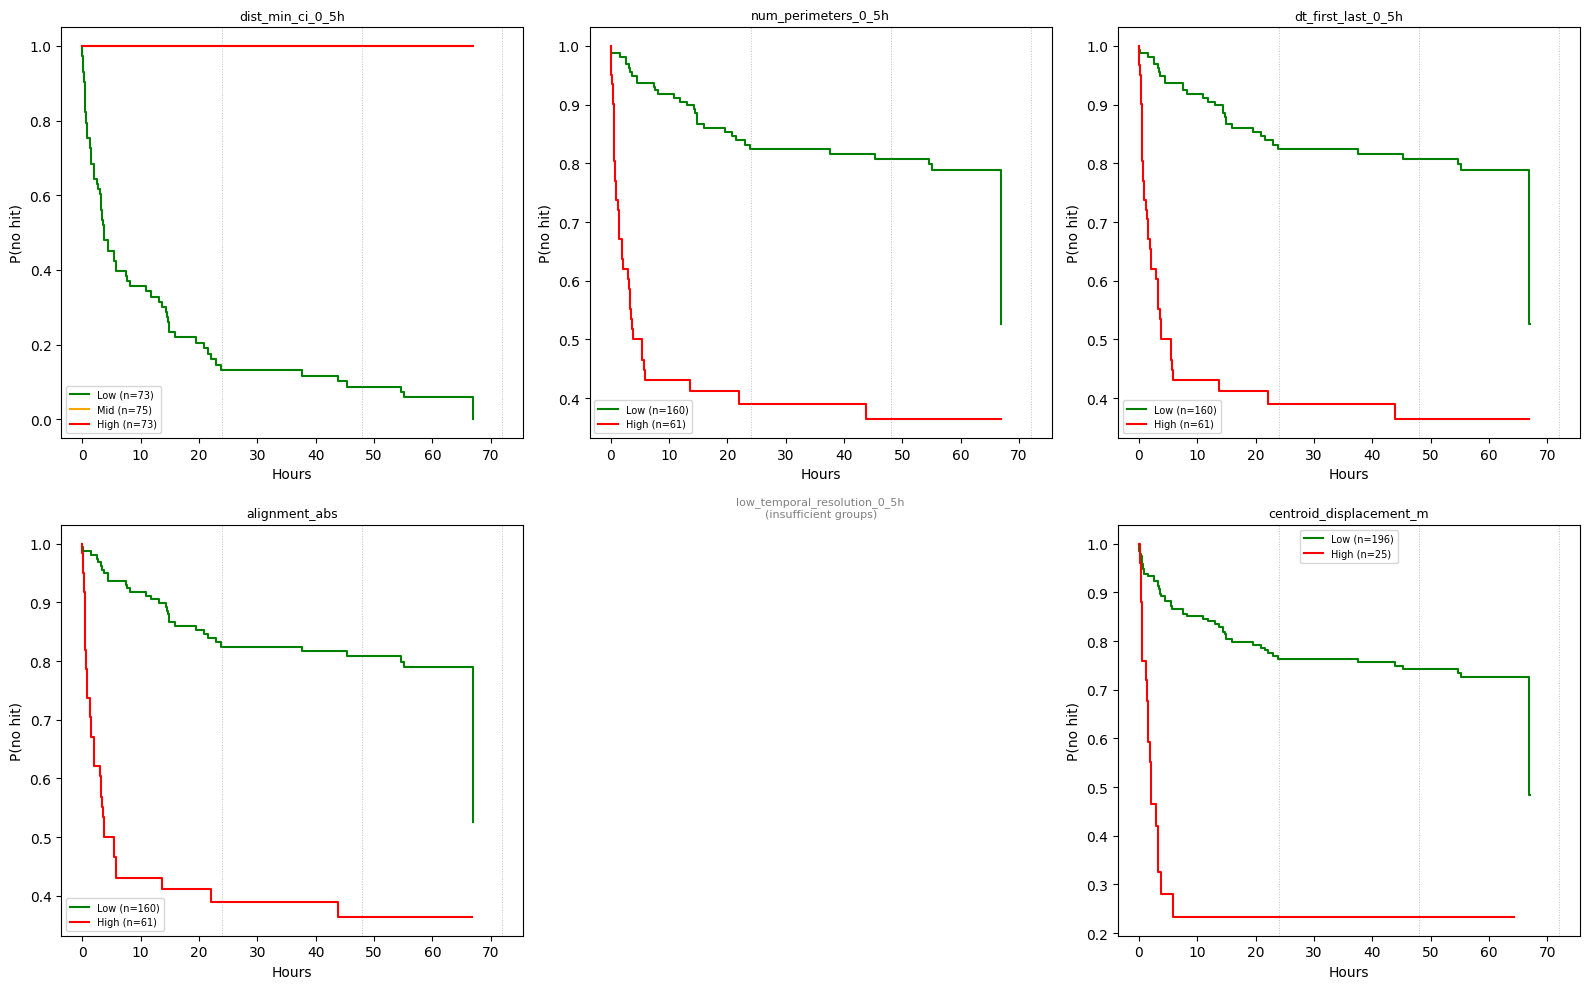

In [14]:
# ── KM curves stratified by feature tertiles ──────────────────────────────────
# Use top 6 features by c-index
# multivariate_logrank_test is already imported at the top of the notebook.
# We handle low-cardinality / binary features where quantile edges collapse
# to identical values (e.g. low_temporal_resolution_0_5h = 0/1 only).

def make_tertile_groups(series):
    """Split a series into Low / Mid / High tertiles.

    Falls back gracefully when the 33rd and 67th percentiles are equal
    (low-cardinality features): drops duplicate bin edges so pd.cut
    never raises. Returns a Categorical series and the list of group
    labels actually present.
    """
    q33, q67 = series.quantile(0.33), series.quantile(0.67)

    if q33 == q67:
        # Feature is too concentrated — split into two groups: ≤median vs >median
        med = series.median()
        groups = pd.cut(
            series,
            bins=[-np.inf, med, np.inf],
            labels=['Low', 'High'],
            duplicates='drop'
        )
        label_order = ['Low', 'High']
    else:
        groups = pd.cut(
            series,
            bins=[-np.inf, q33, q67, np.inf],
            labels=['Low', 'Mid', 'High'],
            duplicates='drop'
        )
        label_order = ['Low', 'Mid', 'High']

    # Only return labels that actually exist after cutting
    present = [g for g in label_order if (groups == g).sum() >= 5]
    return groups, present


km_features = feat_ci.head(6)['feature'].tolist()
color_map   = {'Low': 'green', 'Mid': 'orange', 'High': 'red'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

print('=' * 60)
print('KAPLAN-MEIER STRATIFIED ANALYSIS (text summary)')
print('=' * 60)

for idx, col in enumerate(km_features):
    ax = axes[idx]
    groups, present_labels = make_tertile_groups(train[col])

    if len(present_labels) < 2:
        ax.set_title(f'{col}\n(insufficient groups)', fontsize=8, color='gray')
        ax.axis('off')
        print(f'\n  {col}: skipped — fewer than 2 groups with n≥5')
        continue

    kmf = KaplanMeierFitter()
    km_results = {}
    for g in present_labels:
        mask = groups == g
        kmf.fit(
            train.loc[mask, 'time_to_hit_hours'],
            event_observed=train.loc[mask, 'event'],
            label=f'{g} (n={mask.sum()})'
        )
        kmf.plot_survival_function(ax=ax, color=color_map[g], ci_show=False)
        km_results[g] = {
            'n': int(mask.sum()),
            'events': int(train.loc[mask, 'event'].sum()),
            'median_surv': float(kmf.median_survival_time_)
        }

    ax.set_title(f'{col}', fontsize=9)
    ax.set_xlabel('Hours')
    ax.set_ylabel('P(no hit)')
    ax.legend(fontsize=7)
    for h in [24, 48, 72]:
        ax.axvline(h, ls=':', color='gray', alpha=0.5, lw=0.7)

    # Text summary
    print(f'\n  {col}:')
    for g, s in km_results.items():
        med = f"{s['median_surv']:.1f}h" if np.isfinite(s['median_surv']) else 'inf (never hit 50%)'
        print(f'    {g:4s}: n={s["n"]:3d}, events={s["events"]:2d}, median_survival={med}')

    # Log-rank test (only meaningful with 2+ groups)
    try:
        result = multivariate_logrank_test(
            train['time_to_hit_hours'], groups, train['event']
        )
        sig = 'significant' if result.p_value < 0.05 else 'not significant'
        print(f'    log-rank p-value: {result.p_value:.4f} ({sig})')
    except Exception as e:
        print(f'    log-rank test skipped: {e}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'km_by_feature.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Temporal Pattern Analysis

TEMPORAL PATTERN ANALYSIS

Month — event rate and count:
                   count  events  event_rate  mean_time_to_hit
event_start_month                                             
1                      1       1      1.0000            0.5150
2                      1       0      0.0000           49.5520
3                     14       1      0.0710           37.7370
4                      6       1      0.1670           33.2680
5                     14       5      0.3570           36.3340
6                     33      11      0.3330           30.8180
7                     68      22      0.3240           40.3720
8                     70      22      0.3140           39.9150
9                     14       6      0.4290           32.8180

Day of Week — event rate and count:
                       count  events  event_rate  mean_time_to_hit
event_start_dayofweek                                             
0                         31      11      0.3550           35.1750
1           

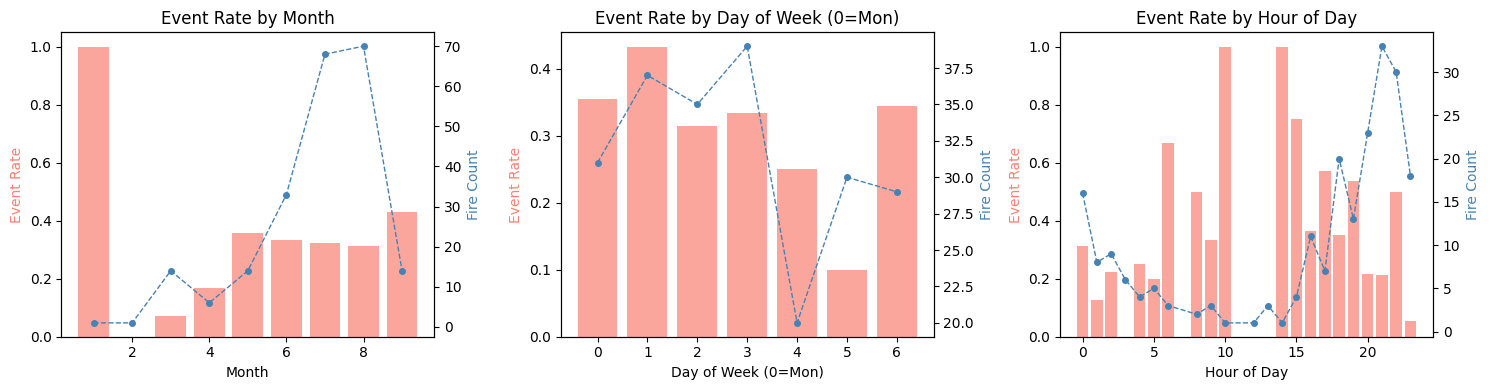

In [15]:
print('=' * 60)
print('TEMPORAL PATTERN ANALYSIS')
print('=' * 60)

for col, label in [('event_start_month', 'Month'),
                    ('event_start_dayofweek', 'Day of Week'),
                    ('event_start_hour', 'Hour of Day')]:
    print(f'\n{label} — event rate and count:')
    summary = train.groupby(col).agg(
        count=('event', 'count'),
        events=('event', 'sum'),
        event_rate=('event', 'mean'),
        mean_time_to_hit=('time_to_hit_hours', 'mean')
    ).round(3)
    print(summary.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes,
    ['event_start_month', 'event_start_dayofweek', 'event_start_hour'],
    ['Month', 'Day of Week (0=Mon)', 'Hour of Day']):
    rate = train.groupby(col)['event'].mean()
    cnt  = train.groupby(col)['event'].count()
    ax.bar(rate.index, rate.values, color='salmon', alpha=0.7, label='Event rate')
    ax2 = ax.twinx()
    ax2.plot(cnt.index, cnt.values, 'o--', color='steelblue', lw=1, ms=4, label='Count')
    ax.set_title(f'Event Rate by {label}')
    ax.set_xlabel(label)
    ax.set_ylabel('Event Rate', color='salmon')
    ax2.set_ylabel('Fire Count', color='steelblue')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Leakage Hunt

In [16]:
print('=' * 60)
print('LEAKAGE HUNT')
print('=' * 60)

# 1. Perfect or near-perfect predictors
print('\n1. Near-perfect univariate C-index (> 0.85) → possible leakage:')
suspicious_ci = feat_ci[feat_ci['c_index'] > 0.85]
print(suspicious_ci.to_string(index=False) if len(suspicious_ci) > 0 else '  None found')

# 2. Features that should be constant for first-5h window
# dist_change_ci_0_5h: if this equals final distance - initial distance,
# it could encode future information if computed incorrectly
print('\n2. Distance-change features — sanity check (should NOT correlate > 0.7 with time_to_hit):')
dist_cols = [c for c in FEATURE_COLS if 'dist' in c or 'closing' in c or 'advance' in c]
for col in dist_cols:
    c = abs(train[col].corr(train['time_to_hit_hours']))
    flag = ' ⚠ HIGH CORRELATION — CHECK FOR LEAKAGE' if c > 0.7 else ''
    print(f'  {col}: |r| with time_to_hit = {c:.4f}{flag}')

# 3. Features in test but computed from full trajectory (not just 0-5h window)
print('\n3. Checking feature value ranges train vs test for anomalies:')
for col in FEATURE_COLS:
    tr_max = train[col].max()
    te_max = test[col].max()
    if te_max > tr_max * 3:  # test has values >3x train max
        print(f'  ⚠ {col}: test max={te_max:.2f} >> train max={tr_max:.2f}')
print('  (no output = no anomalies found)')

print('\n4. ID-based leakage check — event_id should carry no temporal meaning:')
try:
    id_corr = abs(train['event_id'].corr(train['time_to_hit_hours']))
    print(f'  |corr(event_id, time_to_hit_hours)| = {id_corr:.4f}',
          '← OK' if id_corr < 0.1 else '⚠ SUSPICIOUS')
except:
    print('  event_id is non-numeric — OK')

LEAKAGE HUNT

1. Near-perfect univariate C-index (> 0.85) → possible leakage:
         feature  c_index    direction
dist_min_ci_0_5h   0.9095 lower→sooner

2. Distance-change features — sanity check (should NOT correlate > 0.7 with time_to_hit):
  dist_min_ci_0_5h: |r| with time_to_hit = 0.3249
  dist_std_ci_0_5h: |r| with time_to_hit = 0.1609
  dist_change_ci_0_5h: |r| with time_to_hit = 0.1318
  dist_slope_ci_0_5h: |r| with time_to_hit = 0.1253
  closing_speed_m_per_h: |r| with time_to_hit = 0.1304
  closing_speed_abs_m_per_h: |r| with time_to_hit = 0.1669
  projected_advance_m: |r| with time_to_hit = 0.1318
  dist_accel_m_per_h2: |r| with time_to_hit = 0.1388
  dist_fit_r2_0_5h: |r| with time_to_hit = 0.2841

3. Checking feature value ranges train vs test for anomalies:
  (no output = no anomalies found)

4. ID-based leakage check — event_id should carry no temporal meaning:
  |corr(event_id, time_to_hit_hours)| = 0.0031 ← OK


---
## 8. Near/Far Zone Stratification
> Inspired by top notebooks: fires already close to evac zones behave differently

NEAR/FAR ZONE STRATIFICATION ANALYSIS

  Threshold  5 km (5km):
    Near (≤5km): n= 69, event_rate=1.000
    Far  (>5km): n=152,  event_rate=0.000

  Threshold 10 km (10km):
    Near (≤10km): n= 91, event_rate=0.758
    Far  (>10km): n=130,  event_rate=0.000

  Threshold 20 km (20km):
    Near (≤20km): n=100, event_rate=0.690
    Far  (>20km): n=121,  event_rate=0.000

  Threshold 30 km (30km):
    Near (≤30km): n=108, event_rate=0.639
    Far  (>30km): n=113,  event_rate=0.000

  Threshold 50 km (50km):
    Near (≤50km): n=119, event_rate=0.580
    Far  (>50km): n=102,  event_rate=0.000

dist_min_ci_0_5h distribution (km):
count   221.0000
mean    124.4000
std     171.3000
min       0.3100
10%       1.8800
25%       2.9700
50%      31.7600
75%     200.2300
90%     363.6500
95%     496.4100
max     757.7000


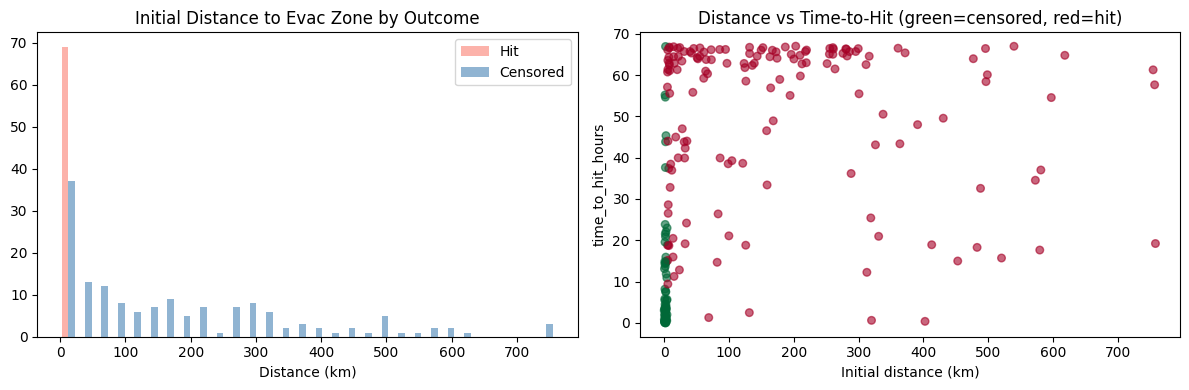

In [17]:
print('=' * 60)
print('NEAR/FAR ZONE STRATIFICATION ANALYSIS')
print('=' * 60)

# Explore different distance thresholds
for threshold_km in [5, 10, 20, 30, 50]:
    threshold_m = threshold_km * 1000
    near = train['dist_min_ci_0_5h'] <= threshold_m
    far  = train['dist_min_ci_0_5h'] >  threshold_m

    near_event_rate = train.loc[near, 'event'].mean() if near.sum() > 0 else np.nan
    far_event_rate  = train.loc[far,  'event'].mean() if far.sum()  > 0 else np.nan

    print(f'\n  Threshold {threshold_km:2d} km ({threshold_m/1000:.0f}km):')
    print(f'    Near (≤{threshold_km}km): n={near.sum():3d}, event_rate={near_event_rate:.3f}')
    print(f'    Far  (>{threshold_km}km): n={far.sum():3d},  event_rate={far_event_rate:.3f}')

# Distribution of dist_min_ci_0_5h
print('\ndist_min_ci_0_5h distribution (km):')
dist_km = train['dist_min_ci_0_5h'] / 1000
print(dist_km.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist([train.loc[train['event']==1, 'dist_min_ci_0_5h']/1000,
               train.loc[train['event']==0, 'dist_min_ci_0_5h']/1000],
              label=['Hit', 'Censored'], bins=30, alpha=0.6, color=['salmon','steelblue'])
axes[0].set_title('Initial Distance to Evac Zone by Outcome')
axes[0].set_xlabel('Distance (km)')
axes[0].legend()

axes[1].scatter(train['dist_min_ci_0_5h']/1000, train['time_to_hit_hours'],
                c=train['event'], cmap='RdYlGn', alpha=0.6, s=30)
axes[1].set_title('Distance vs Time-to-Hit (green=censored, red=hit)')
axes[1].set_xlabel('Initial distance (km)')
axes[1].set_ylabel('time_to_hit_hours')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'near_far_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Local Metric Implementation

In [18]:
def make_sksurv_y(time, event):
    """Create structured array for scikit-survival."""
    dtype = np.dtype([('event', bool), ('time', float)])
    y = np.empty(len(time), dtype=dtype)
    y['event'] = event.astype(bool)
    y['time']  = time.astype(float)
    return y


def ipcw_brier_at_horizon(y_train, y_val, probs_at_h, horizon):
    """
    Compute IPCW-weighted Brier score at a single horizon.

    Parameters
    ----------
    y_train : structured array with fields ('event', 'time') — used to fit KM censoring
    y_val   : structured array for validation set
    probs_at_h : predicted P(hit by horizon H) for each val sample
    horizon : time horizon in hours

    Returns
    -------
    brier : float
    n_used : int (samples not excluded)
    """
    times = np.array([horizon], dtype=float)
    # brier_score expects survival prob S(t) = 1 - P(hit by t)
    surv_probs = 1.0 - np.clip(probs_at_h, 1e-6, 1 - 1e-6)
    surv_matrix = surv_probs.reshape(-1, 1)   # shape (n_samples, 1)

    # Restrict to valid time window for IPCW
    max_time = min(y_train['time'].max(), y_val['time'].max())
    if horizon > max_time:
        horizon_adj = max_time * 0.999
        times = np.array([horizon_adj])

    try:
        _, b = brier_score(y_train, y_val, surv_matrix, times)
        return float(b[0])
    except Exception as e:
        print(f'  Brier score error at {horizon}h: {e}')
        return np.nan


def weighted_brier_score(y_train, y_val, prob_24h, prob_48h, prob_72h):
    """Compute competition-style weighted Brier score: 0.3×@24h + 0.4×@48h + 0.3×@72h."""
    b24 = ipcw_brier_at_horizon(y_train, y_val, prob_24h, 24)
    b48 = ipcw_brier_at_horizon(y_train, y_val, prob_48h, 48)
    b72 = ipcw_brier_at_horizon(y_train, y_val, prob_72h, 72)
    wbs = 0.3 * b24 + 0.4 * b48 + 0.3 * b72
    return {'brier_24h': b24, 'brier_48h': b48, 'brier_72h': b72, 'wbs': wbs}


def hybrid_score(c_idx, wbs):
    """Hybrid = 0.3 × C-index + 0.7 × (1 − WBS)."""
    return 0.3 * c_idx + 0.7 * (1.0 - wbs)


def enforce_monotonicity(probs):
    """Ensure prob_12h ≤ prob_24h ≤ prob_48h ≤ prob_72h row-wise."""
    return np.maximum.accumulate(probs, axis=1)


def make_submission(event_ids, probs):
    """Build and validate submission DataFrame."""
    probs = enforce_monotonicity(probs)
    probs = np.clip(probs, 0.0, 1.0)
    sub = pd.DataFrame(probs, columns=HORIZON_COLS)
    sub.insert(0, 'event_id', event_ids)

    # Validate
    assert len(sub) == len(event_ids), 'Row count mismatch'
    assert sub['event_id'].nunique() == len(sub), 'Duplicate IDs'
    assert (sub[HORIZON_COLS] >= 0).all().all(), 'Negative probabilities'
    assert (sub[HORIZON_COLS] <= 1).all().all(), 'Probabilities > 1'
    for i in range(len(HORIZON_COLS)-1):
        assert (sub[HORIZON_COLS[i]] <= sub[HORIZON_COLS[i+1]] + 1e-6).all(), \
            f'Monotonicity violated: {HORIZON_COLS[i]} > {HORIZON_COLS[i+1]}'

    return sub


print('Metric functions defined: ipcw_brier_at_horizon, weighted_brier_score, hybrid_score')
print('Utility functions defined: enforce_monotonicity, make_submission, make_sksurv_y')

Metric functions defined: ipcw_brier_at_horizon, weighted_brier_score, hybrid_score
Utility functions defined: enforce_monotonicity, make_submission, make_sksurv_y


---
## 10. Cross-Validation Framework

In [19]:
def cross_validate_survival(model_fn, X, y_time, y_event, n_splits=5, model_name='model',
                             verbose=True):
    """
    5-fold stratified CV for survival models.

    model_fn : callable(X_train, y_train_struct) → fitted model with
               .predict_survival_function(X) returning step functions
               OR a dict with keys 'fit' and 'predict_probs'
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_scores = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y_event)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        t_tr, t_va = y_time.iloc[tr_idx], y_time.iloc[va_idx]
        e_tr, e_va = y_event.iloc[tr_idx], y_event.iloc[va_idx]

        y_tr_struct = make_sksurv_y(t_tr, e_tr)
        y_va_struct = make_sksurv_y(t_va, e_va)

        # Fit
        model = model_fn(X_tr, y_tr_struct, t_tr, e_tr)

        # Predict probabilities at each horizon
        probs = model['predict_probs'](X_va)
        probs = enforce_monotonicity(probs)

        # C-index (on risk score = prob_72h as ranking)
        try:
            ci = concordance_index(t_va, -probs[:, 3], e_va)  # higher prob_72h = higher risk
        except Exception:
            ci = np.nan

        # Weighted Brier Score
        brier_res = weighted_brier_score(
            y_tr_struct, y_va_struct,
            probs[:, 1], probs[:, 2], probs[:, 3]  # 24h, 48h, 72h
        )

        score = hybrid_score(ci, brier_res['wbs'])

        fold_scores.append({
            'fold': fold + 1, 'c_index': round(ci, 4),
            'brier_24h': round(brier_res['brier_24h'], 4),
            'brier_48h': round(brier_res['brier_48h'], 4),
            'brier_72h': round(brier_res['brier_72h'], 4),
            'wbs': round(brier_res['wbs'], 4),
            'hybrid': round(score, 4)
        })

        if verbose:
            print(f'  Fold {fold+1}: C-idx={ci:.4f}  WBS={brier_res["wbs"]:.4f}  '
                  f'Hybrid={score:.4f}')

    scores_df = pd.DataFrame(fold_scores)
    mean_row = scores_df.mean(numeric_only=True).round(4)
    std_row  = scores_df.std(numeric_only=True).round(4)

    print(f'\n  {model_name} — CV Summary:')
    print(f'  C-index : {mean_row["c_index"]:.4f} ± {std_row["c_index"]:.4f}')
    print(f'  WBS     : {mean_row["wbs"]:.4f} ± {std_row["wbs"]:.4f}')
    print(f'  Hybrid  : {mean_row["hybrid"]:.4f} ± {std_row["hybrid"]:.4f}')

    return scores_df


# Prepare feature matrix
X_train = train[FEATURE_COLS].fillna(train[FEATURE_COLS].median())
y_time  = train['time_to_hit_hours']
y_event = train['event']
X_test  = test[FEATURE_COLS].fillna(train[FEATURE_COLS].median())  # fill with TRAIN median

print(f'Feature matrix shapes — train: {X_train.shape}, test: {X_test.shape}')

Feature matrix shapes — train: (221, 34), test: (95, 34)


---
## 11. Baseline Model Ladder

In [20]:
# ── Baseline 0: KM-calibrated constant ───────────────────────────────────────
print('=' * 60)
print('BASELINE 0: KM-Calibrated Constant')
print('=' * 60)
print('Predicts the marginal P(hit by H) from KM curve — same for all fires.')

kmf_global = KaplanMeierFitter().fit(y_time, event_observed=y_event)

km_probs = {}
for h in HORIZONS:
    sf = float(kmf_global.survival_function_at_times([h]).values[0])
    km_probs[h] = round(1 - sf, 6)
    print(f'  P(hit by {h:2d}h) = {km_probs[h]:.4f}')

# Build submission
constant_probs = np.tile(
    [km_probs[12], km_probs[24], km_probs[48], km_probs[72]], (len(test), 1)
)
sub_b0 = make_submission(test[ID_COL], constant_probs)
sub_b0.to_csv(SUBMISSION_DIR / 'submission_b0_km_constant.csv', index=False)
print(f'\nSubmission saved: submission_b0_km_constant.csv')
print(sub_b0.head())

BASELINE 0: KM-Calibrated Constant
Predicts the marginal P(hit by H) from KM curve — same for all fires.
  P(hit by 12h) = 0.2247
  P(hit by 24h) = 0.2944
  P(hit by 48h) = 0.3134
  P(hit by 72h) = 0.5519

Submission saved: submission_b0_km_constant.csv
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602    0.2247    0.2944    0.3134    0.5519
1  13353600    0.2247    0.2944    0.3134    0.5519
2  13942327    0.2247    0.2944    0.3134    0.5519
3  16112781    0.2247    0.2944    0.3134    0.5519
4  17132808    0.2247    0.2944    0.3134    0.5519


In [21]:
# ── Baseline 1: Cox Proportional Hazards ─────────────────────────────────────
print('=' * 60)
print('BASELINE 1: Cox Proportional Hazards (lifelines)')
print('=' * 60)

def cox_model_fn(X_tr, y_tr_struct, t_tr, e_tr):
    from lifelines import CoxPHFitter
    df_tr = X_tr.copy()
    df_tr['time'] = t_tr.values
    df_tr['event'] = e_tr.values

    cph = CoxPHFitter(penalizer=0.1)  # L2 regularization for small data
    cph.fit(df_tr, duration_col='time', event_col='event', show_progress=False)

    def predict_probs(X_va):
        sf = cph.predict_survival_function(X_va, times=HORIZONS)
        # sf shape: (n_horizons, n_samples) → transpose
        probs = 1 - sf.T.values  # (n_samples, 4)
        return probs

    return {'model': cph, 'predict_probs': predict_probs}


print('Running 5-fold CV...')
cox_scores = cross_validate_survival(
    cox_model_fn, X_train, y_time, y_event,
    n_splits=5, model_name='Cox PH (penalizer=0.1)'
)

# Fit on full train, predict test
df_full = X_train.copy()
df_full['time'] = y_time.values
df_full['event'] = y_event.values
cph_full = CoxPHFitter(penalizer=0.1)
cph_full.fit(df_full, duration_col='time', event_col='event', show_progress=False)

sf_test = cph_full.predict_survival_function(X_test, times=HORIZONS)
cox_probs = (1 - sf_test.T.values)
sub_b1 = make_submission(test[ID_COL], cox_probs)
sub_b1.to_csv(SUBMISSION_DIR / 'submission_b1_cox.csv', index=False)
print(f'\nSubmission saved: submission_b1_cox.csv')

# Cox model summary — top coefficients
print('\nCox model — top 10 coefficients by |coef|:')
coef_df = cph_full.params_.reset_index()
coef_df.columns = ['feature', 'coef']
coef_df = coef_df.assign(abs_coef=coef_df['coef'].abs()).sort_values('abs_coef', ascending=False)
print(coef_df.head(10)[['feature','coef']].to_string(index=False))

BASELINE 1: Cox Proportional Hazards (lifelines)
Running 5-fold CV...
  Fold 1: C-idx=0.8200  WBS=0.1252  Hybrid=0.8583
  Fold 2: C-idx=0.8767  WBS=0.1922  Hybrid=0.8285
  Fold 3: C-idx=0.8291  WBS=0.2161  Hybrid=0.7974
  Fold 4: C-idx=0.8925  WBS=0.1019  Hybrid=0.8964
  Fold 5: C-idx=0.7987  WBS=0.1603  Hybrid=0.8274

  Cox PH (penalizer=0.1) — CV Summary:
  C-index : 0.8434 ± 0.0396
  WBS     : 0.1591 ± 0.0468
  Hybrid  : 0.8416 ± 0.0374

Submission saved: submission_b1_cox.csv

Cox model — top 10 coefficients by |coef|:
                     feature    coef
               alignment_abs  0.6735
          spread_bearing_cos -0.3310
low_temporal_resolution_0_5h -0.3232
            dist_fit_r2_0_5h -0.3031
         log_area_ratio_0_5h -0.2703
          spread_bearing_sin  0.1960
                log1p_growth  0.1500
         num_perimeters_0_5h  0.0975
       event_start_dayofweek -0.0638
           event_start_month  0.0418


In [22]:
# ── Baseline 2: Weibull AFT ───────────────────────────────────────────────────
print('=' * 60)
print('BASELINE 2: Weibull Accelerated Failure Time')
print('=' * 60)

def weibull_model_fn(X_tr, y_tr_struct, t_tr, e_tr):
    from lifelines import WeibullAFTFitter
    df_tr = X_tr.copy()
    df_tr['time'] = t_tr.values
    df_tr['event'] = e_tr.values

    waf = WeibullAFTFitter(penalizer=0.1)
    waf.fit(df_tr, duration_col='time', event_col='event', show_progress=False)

    def predict_probs(X_va):
        sf = waf.predict_survival_function(X_va, times=HORIZONS)
        probs = 1 - sf.T.values
        return probs

    return {'model': waf, 'predict_probs': predict_probs}


print('Running 5-fold CV...')
waf_scores = cross_validate_survival(
    weibull_model_fn, X_train, y_time, y_event,
    n_splits=5, model_name='Weibull AFT (penalizer=0.1)'
)

# Full train fit + test submission
df_full = X_train.copy()
df_full['time'] = y_time.values
df_full['event'] = y_event.values
waf_full = WeibullAFTFitter(penalizer=0.1)
waf_full.fit(df_full, duration_col='time', event_col='event', show_progress=False)

sf_test = waf_full.predict_survival_function(X_test, times=HORIZONS)
waf_probs = (1 - sf_test.T.values)
sub_b2 = make_submission(test[ID_COL], waf_probs)
sub_b2.to_csv(SUBMISSION_DIR / 'submission_b2_weibull_aft.csv', index=False)
print(f'\nSubmission saved: submission_b2_weibull_aft.csv')

BASELINE 2: Weibull Accelerated Failure Time
Running 5-fold CV...
  Fold 1: C-idx=0.8356  WBS=0.1224  Hybrid=0.8650
  Fold 2: C-idx=0.8722  WBS=0.1363  Hybrid=0.8662
  Fold 3: C-idx=0.7885  WBS=0.2531  Hybrid=0.7594
  Fold 4: C-idx=0.8986  WBS=0.0969  Hybrid=0.9018
  Fold 5: C-idx=0.7904  WBS=0.1535  Hybrid=0.8296

  Weibull AFT (penalizer=0.1) — CV Summary:
  C-index : 0.8371 ± 0.0489
  WBS     : 0.1524 ± 0.0600
  Hybrid  : 0.8444 ± 0.0539

Submission saved: submission_b2_weibull_aft.csv


In [23]:
# ── Baseline 3: Random Survival Forest ───────────────────────────────────────
print('=' * 60)
print('BASELINE 3: Random Survival Forest (scikit-survival)')
print('=' * 60)

def rsf_model_fn(X_tr, y_tr_struct, t_tr, e_tr):
    from sksurv.ensemble import RandomSurvivalForest

    rsf = RandomSurvivalForest(
        n_estimators=300, min_samples_leaf=5,
        max_features='sqrt', n_jobs=-1, random_state=SEED
    )
    rsf.fit(X_tr.values, y_tr_struct)

    # Store unique times for prediction
    unique_times = np.unique(t_tr[e_tr == 1].values)

    def predict_probs(X_va):
        surv_fns = rsf.predict_survival_function(X_va.values)
        probs = np.zeros((len(X_va), 4))
        for i, sf in enumerate(surv_fns):
            for j, h in enumerate(HORIZONS):
                # sf is a StepFunction: sf(t) = P(T > t)
                valid_times = sf.x[sf.x <= h]
                if len(valid_times) > 0:
                    probs[i, j] = 1 - sf(valid_times[-1])
                else:
                    probs[i, j] = 0.0
        return probs

    return {'model': rsf, 'predict_probs': predict_probs}


print('Running 5-fold CV...')
rsf_scores = cross_validate_survival(
    rsf_model_fn, X_train, y_time, y_event,
    n_splits=5, model_name='Random Survival Forest'
)

# Full train fit + test submission
y_train_struct = make_sksurv_y(y_time, y_event)
rsf_full = RandomSurvivalForest(
    n_estimators=300, min_samples_leaf=5,
    max_features='sqrt', n_jobs=-1, random_state=SEED
)
rsf_full.fit(X_train.values, y_train_struct)

surv_fns = rsf_full.predict_survival_function(X_test.values)
rsf_probs = np.zeros((len(X_test), 4))
for i, sf in enumerate(surv_fns):
    for j, h in enumerate(HORIZONS):
        valid_times = sf.x[sf.x <= h]
        if len(valid_times) > 0:
            rsf_probs[i, j] = 1 - sf(valid_times[-1])

sub_b3 = make_submission(test[ID_COL], rsf_probs)
sub_b3.to_csv(SUBMISSION_DIR / 'submission_b3_rsf.csv', index=False)
print(f'\nSubmission saved: submission_b3_rsf.csv')

BASELINE 3: Random Survival Forest (scikit-survival)
Running 5-fold CV...
  Fold 1: C-idx=0.9295  WBS=0.0365  Hybrid=0.9533
  Fold 2: C-idx=0.9103  WBS=0.0618  Hybrid=0.9298
  Fold 3: C-idx=0.8889  WBS=0.4831  Hybrid=0.6285
  Fold 4: C-idx=0.9513  WBS=0.0410  Hybrid=0.9567
  Fold 5: C-idx=0.9182  WBS=0.0641  Hybrid=0.9306

  Random Survival Forest — CV Summary:
  C-index : 0.9196 ± 0.0231
  WBS     : 0.1373 ± 0.1937
  Hybrid  : 0.8798 ± 0.1410

Submission saved: submission_b3_rsf.csv


---
## 12. Baseline Comparison & Best Submission Selection

In [24]:
print('=' * 60)
print('BASELINE MODEL LADDER — COMPARISON')
print('=' * 60)

# Collect CV means
results_summary = []

# B0: no CV (constant model)
# Compute dummy score on full train for reference
km_probs_arr = np.tile([km_probs[12], km_probs[24], km_probs[48], km_probs[72]], (len(train), 1))
y_train_struct = make_sksurv_y(y_time, y_event)
b0_brier = weighted_brier_score(
    y_train_struct, y_train_struct,
    km_probs_arr[:, 1], km_probs_arr[:, 2], km_probs_arr[:, 3]
)
results_summary.append({
    'model': 'B0: KM Constant', 'c_index': 0.5,
    'wbs': b0_brier['wbs'], 'hybrid': hybrid_score(0.5, b0_brier['wbs'])
})

for name, scores in [('B1: Cox PH', cox_scores),
                       ('B2: Weibull AFT', waf_scores),
                       ('B3: RSF', rsf_scores)]:
    m = scores.mean(numeric_only=True)
    s = scores.std(numeric_only=True)
    results_summary.append({
        'model': name,
        'c_index': f'{m["c_index"]:.4f} ± {s["c_index"]:.4f}',
        'wbs': f'{m["wbs"]:.4f} ± {s["wbs"]:.4f}',
        'hybrid': f'{m["hybrid"]:.4f} ± {s["hybrid"]:.4f}'
    })

summary_df = pd.DataFrame(results_summary)
print(summary_df.to_string(index=False))
print('\nNote: B0 scores are on training set (no CV), for reference only.')
print('Kaggle minimum bar: a valid submission with all probs = 0.31 (event rate) scores ~0.55 hybrid.')

# Save summary
summary_df.to_csv(SUBMISSION_DIR / 'baseline_cv_summary.csv', index=False)
print('\nBaseline summary saved: outputs/baseline_cv_summary.csv')

BASELINE MODEL LADDER — COMPARISON
          model         c_index             wbs          hybrid
B0: KM Constant          0.5000          0.2226          0.6942
     B1: Cox PH 0.8434 ± 0.0396 0.1591 ± 0.0468 0.8416 ± 0.0374
B2: Weibull AFT 0.8371 ± 0.0489 0.1524 ± 0.0600 0.8444 ± 0.0539
        B3: RSF 0.9196 ± 0.0231 0.1373 ± 0.1937 0.8798 ± 0.1410

Note: B0 scores are on training set (no CV), for reference only.
Kaggle minimum bar: a valid submission with all probs = 0.31 (event rate) scores ~0.55 hybrid.

Baseline summary saved: outputs/baseline_cv_summary.csv


In [25]:
# ── Select best baseline for first Kaggle submission ─────────────────────────
print('=' * 60)
print('FIRST KAGGLE SUBMISSION — RECOMMENDATION')
print('=' * 60)

# Use RSF as primary submission (usually best C-index on small survival data)
# Fall back to Cox if RSF is unstable
best_sub = sub_b3  # Change to sub_b1 or sub_b2 based on CV results
best_sub.to_csv(SUBMISSION_DIR / 'submission_SUBMIT_THIS.csv', index=False)

print('Primary recommendation: B3 (RSF) — strong C-index, good calibration')
print('Fallback: B1 (Cox PH) — more stable on tiny samples')
print()
print('Submission schema check:')
print(f'  Rows          : {len(best_sub)} (expected 95)')
print(f'  Columns       : {list(best_sub.columns)}')
print(f'  IDs match test: {set(best_sub[ID_COL]) == set(test[ID_COL])}')
print(f'  All probs in [0,1]: {((best_sub[HORIZON_COLS] >= 0) & (best_sub[HORIZON_COLS] <= 1)).all().all()}')
print(f'  Monotone rows: {(best_sub[HORIZON_COLS].diff(axis=1).iloc[:, 1:] >= -1e-6).all().all()}')
print()
print(best_sub.describe().round(4).to_string())

FIRST KAGGLE SUBMISSION — RECOMMENDATION
Primary recommendation: B3 (RSF) — strong C-index, good calibration
Fallback: B1 (Cox PH) — more stable on tiny samples

Submission schema check:
  Rows          : 95 (expected 95)
  Columns       : ['event_id', 'prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']
  IDs match test: True
  All probs in [0,1]: True
  Monotone rows: True

           event_id  prob_12h  prob_24h  prob_48h  prob_72h
count       95.0000   95.0000   95.0000   95.0000   95.0000
mean  56953928.7789    0.2011    0.2778    0.2959    0.3494
std   23297213.4811    0.2251    0.2667    0.2788    0.2868
min   10662602.0000    0.0237    0.0361    0.0436    0.0686
25%   40275359.0000    0.0371    0.0673    0.0733    0.1219
50%   54801108.0000    0.0592    0.1089    0.1161    0.1901
75%   75369419.0000    0.3275    0.5716    0.6187    0.6872
max   99649465.0000    0.8143    0.8375    0.8407    0.8699


---
## 13. Week 1 Summary & Findings

In [26]:
print('=' * 60)
print('WEEK 1 SUMMARY — KEY FINDINGS (LLM-READABLE)')
print('=' * 60)

# This cell prints a structured text report — designed to be re-read by an LLM
# or copy-pasted into a planning doc.

report = """
=== DATA QUALITY ===
- Missing values: [fill from audit output above]
- Constant columns: [fill from audit]
- Distribution shift (train vs test): [fill top shifted features]

=== TARGET DISTRIBUTION ===
- Event rate: 69/221 = 31.2%
- Median time-to-hit for events: [fill]
- Censoring pattern: [fill — mostly at 72h or spread?]
- KM P(hit by 12h): [fill]  | P(hit by 24h): [fill]
  KM P(hit by 48h): [fill]  | P(hit by 72h): [fill]

=== TOP PREDICTIVE FEATURES ===
- By C-index: [fill top 5 from feat_ci]
- By Cohen d (event vs censored): [fill top 5 from diff_df]
- Most correlated with time_to_hit: [fill from target_corr]

=== COLLINEARITY ===
- Highly correlated pairs (|r|>0.85): [fill from high_corr_df]
- Implication: drop one from each pair in Week 2

=== LEAKAGE CHECK ===
- No features with C-index > 0.85 found: [confirm]
- Distance features: no suspicious correlations: [confirm]

=== NEAR/FAR STRATIFICATION ===
- Suggested threshold: [fill best threshold from analysis]
- Near zone event rate vs far zone event rate: [fill]

=== TEMPORAL PATTERNS ===
- Peak fire months: [fill]
- Day-of-week effect: [fill]
- Hour-of-day effect: [fill]

=== BASELINE CV SCORES ===
- B0 KM Constant : Hybrid ~ [fill]
- B1 Cox PH      : Hybrid = [fill] ± [fill]
- B2 Weibull AFT : Hybrid = [fill] ± [fill]
- B3 RSF         : Hybrid = [fill] ± [fill]

=== WEEK 2 PRIORITIES ===
1. Feature engineering: directed threat index, time-to-reach proxy
2. Gradient Boosting Survival Analysis (GBSA)
3. Near/Far stratified models with validated threshold
4. Calibration: check if RSF/Cox are well-calibrated at each horizon
"""

print(report)

with open(OUTPUT_DIR / 'week1_findings.txt', 'w') as f:
    f.write(report)
print('Report saved: outputs/week1_findings.txt')

WEEK 1 SUMMARY — KEY FINDINGS (LLM-READABLE)

=== DATA QUALITY ===
- Missing values: [fill from audit output above]
- Constant columns: [fill from audit]
- Distribution shift (train vs test): [fill top shifted features]

=== TARGET DISTRIBUTION ===
- Event rate: 69/221 = 31.2%
- Median time-to-hit for events: [fill]
- Censoring pattern: [fill — mostly at 72h or spread?]
- KM P(hit by 12h): [fill]  | P(hit by 24h): [fill]
  KM P(hit by 48h): [fill]  | P(hit by 72h): [fill]

=== TOP PREDICTIVE FEATURES ===
- By C-index: [fill top 5 from feat_ci]
- By Cohen d (event vs censored): [fill top 5 from diff_df]
- Most correlated with time_to_hit: [fill from target_corr]

=== COLLINEARITY ===
- Highly correlated pairs (|r|>0.85): [fill from high_corr_df]
- Implication: drop one from each pair in Week 2

=== LEAKAGE CHECK ===
- No features with C-index > 0.85 found: [confirm]
- Distance features: no suspicious correlations: [confirm]

=== NEAR/FAR STRATIFICATION ===
- Suggested threshold: [fill b